# Bag of Words Classifier

This notebook shows a simple sentiment classifier using Bag of Words and a neural network.

## 1. Import libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from tqdm import tqdm
import re

## 2. Load and preprocess data

In [20]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d', ' ', text)
    return text.strip()

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")

train_texts = [preprocess_text(t) for t in ds['train']['text']]
test_texts = [preprocess_text(t) for t in ds['test']['text']]
train_labels = ds['train']['label']
test_labels = ds['test']['label']

## 3. Build vocabulary
Create a dictionary of all unique words from training reviews.

In [21]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for sentence in texts:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab

vocab = build_vocab(train_texts)
print(f'Word count in vocabulary: {len(vocab)}')

Word count in vocabulary: 16351


## 4. Convert reviews to Bag of Words vectors
Transform each review into a Bag of Words vector using the vocabulary.

In [22]:
def text_to_bow(text, vocab):
    vec = np.zeros(len(vocab), dtype=np.float32)
    for word in text.split():
        if word in vocab:
            idx = vocab[word]
            vec[idx] += 1
    return vec

X_train = np.array([text_to_bow(text, vocab) for text in train_texts])
X_test = np.array([text_to_bow(text, vocab) for text in test_texts])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f'BoW vector example: {X_train[0][:10]}')

BoW vector example: [2. 1. 1. 1. 2. 1. 1. 1. 2. 1.]


## 5. Define model
Simple model: one linear layer and sigmoid activation.

In [23]:
class BoWClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

input_dim = X_train.shape[1]
model = BoWClassifier(input_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

cuda


## 6. Training
Train the model using binary cross-entropy loss.

In [24]:
lr = 0.01
epochs = 15
batch_size = 64
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCELoss()
model.to(device)

accuracy_list = []
for epoch in tqdm(range(epochs)):
    model.train()
    permutation = torch.randperm(X_train_tensor.size()[0])
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        preds = (test_outputs > 0.5).float()
        acc = (preds == y_test_tensor).float().mean().item()
        accuracy_list.append(acc)
    print(f'Epoch {epoch+1}/{epochs}, Accuracy: {acc:.4f}')

 13%|█▎        | 2/15 [00:00<00:01, 12.15it/s]

Epoch 1/15, Accuracy: 0.7786
Epoch 2/15, Accuracy: 0.7833
Epoch 3/15, Accuracy: 0.7946


 40%|████      | 6/15 [00:00<00:00, 12.76it/s]

Epoch 4/15, Accuracy: 0.7927
Epoch 5/15, Accuracy: 0.7880
Epoch 6/15, Accuracy: 0.7852


 53%|█████▎    | 8/15 [00:00<00:00, 12.76it/s]

Epoch 7/15, Accuracy: 0.7889
Epoch 8/15, Accuracy: 0.7852
Epoch 9/15, Accuracy: 0.7852


 80%|████████  | 12/15 [00:00<00:00, 12.98it/s]

Epoch 10/15, Accuracy: 0.7814
Epoch 11/15, Accuracy: 0.7871
Epoch 12/15, Accuracy: 0.7871


100%|██████████| 15/15 [00:01<00:00, 13.07it/s]

Epoch 13/15, Accuracy: 0.7899
Epoch 14/15, Accuracy: 0.7871
Epoch 15/15, Accuracy: 0.7880


## 7. Accuracy plot
Plot test accuracy over epochs.

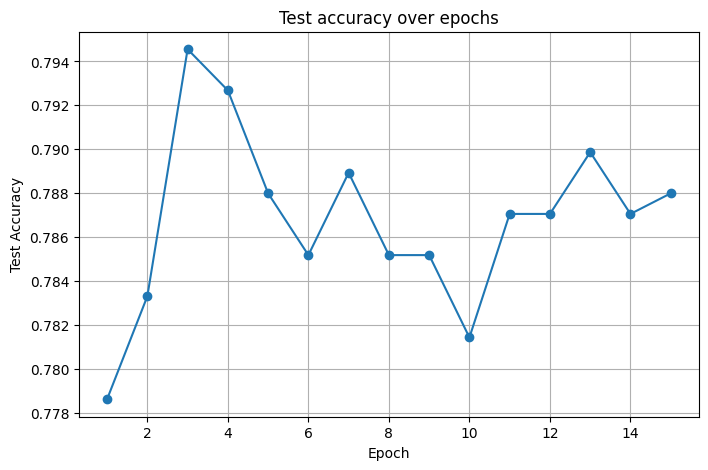

In [26]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy_list)+1), accuracy_list, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test accuracy over epochs')
plt.grid(True)
plt.show()

## 8. Results
The model’s test accuracy starts around 78% and peaks at about 79% in the third epoch. After that, accuracy stays pretty stable and doesn’t improve much. This means the Bag of Words model quickly learns what it can from the data, but its performance is limited. The early peak and plateau suggest the model can’t capture more complex patterns, probably because Bag of Words ignores word order and context. For better results, more advanced models or features would be needed.